# Synthetic-only classification run 11
This notebook trains a three-class classifier using synthetic-only data. It includes dataset loading, class-specific augmentation, transfer learning with EfficientNetB4, evaluation on a held-out test set, and visualization of results with confusion matrices and Grad-CAM.

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from pathlib import Path
from collections import defaultdict
from collections import Counter
import random

In [ ]:

# Dataset locations for training, validation, and test splits.
base_dir = r"F:\Users\Nikol\Desktop\Data\Splits1"
train_dir = fr"{base_dir}\train"
val_dir = fr"{base_dir}\val"
test_dir = fr"{base_dir}\test"

# Training settings and image preprocessing parameters.
img_size = (682, 1024)   # (height, width)
batch_size = 4
seed = 42
num_classes = 3

# Load datasets from directory structure.
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=seed,
    crop_to_aspect_ratio=True,
)

val_ds = keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="int",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,
    crop_to_aspect_ratio=True,
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,
    crop_to_aspect_ratio=True,
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Use prefetching to improve IO performance.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# Augmentation for most classes.
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
])

# Stronger augmentation for the t72 class.
t72_aug = keras.Sequential([
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.3),
    layers.RandomContrast(0.3),
])

# Loads a single class directory and apply the augmentation pipeline.
def load_class_ds(class_path, label, img_size, augmentation):
    ds = keras.utils.image_dataset_from_directory(
        class_path,
        labels=None,
        image_size=img_size,
        batch_size=None,
        shuffle=True,
        seed=42,
    )
    ds = ds.map(lambda img: (augmentation(img, training=True), tf.cast(label, tf.int32)))
    return ds

# Loads each class separately for class-specific augmentation.
t72_ds = load_class_ds(fr"{train_dir}\t72", 0, img_size, t72_aug)
t80_ds = load_class_ds(fr"{train_dir}\t80", 1, img_size, data_augmentation)
t90_ds = load_class_ds(fr"{train_dir}\t90", 2, img_size, data_augmentation)

train_ds = (t72_ds
    .concatenate(t80_ds)
    .concatenate(t90_ds)
    .shuffle(buffer_size=1000, seed=42)
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

# Transfer learning backbone using EfficientNetB4.
base_model = keras.applications.EfficientNetB4(
    input_shape=img_size + (3,),
    include_top=False,
    weights="imagenet",
)

# Freezing early layers and fine-tune only the last layers.
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

trainable_count = sum(layer.trainable for layer in base_model.layers)
print(f"Trainable layers in base_model: {trainable_count}/{len(base_model.layers)}")

inputs = keras.Input(shape=img_size + (3,))
x = keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-3))(x)
x = layers.Dropout(0.6)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="tank_classifier")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

# Callbacks for early stopping and automatic learning rate reduction.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
)
# Evaluate and save the model after training.
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")

model.save(r"F:\Users\Nikol\Desktop\Data\tank_classifier.keras")
print("Model saved.")


Found 2880 files belonging to 3 classes.
Found 960 files belonging to 3 classes.
Found 960 files belonging to 3 classes.
Classes: ['t72', 't80', 't90']
Found 960 files.
Found 960 files.
Found 960 files.
Trainable layers in base_model: 40/475


Model: "tank_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 682, 1024, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 22, 32, 1792)   │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       229,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,903,714 (68.30 MB)

 Trainable params: 6,174,395 (23.55 MB)

 Non-trainable params: 11,729,319 (44.74 MB)

Epoch 1/50
720/720 ━━━━━━━━━━━━━━━━━━━━ 802s 1s/step - accuracy: 0.5545 - loss: 1.2130 - val_accuracy: 0.6260 - val_loss: 1.2244 - learning_rate: 1.0000e-05
Epoch 2/50
720/720 ━━━━━━━━━━━━━━━━━━━━ 769s 1s/step - accuracy: 0.7045 - loss: 1.0276 - val_accuracy: 0.6490 - val_loss: 1.0957 - learning_rate: 1.0000e-05
Epoch 3/50
720/720 ━━━━━━━━━━━━━━━━━━━━ 770s 1s/step - accuracy: 0.7854 - loss: 0.8193 - val_accuracy: 0.7177 - val_loss: 0.9545 - learning_rate: 1.0000e-05
Epoch 4/50
720/720 ━━━━━━━━━━━━━━━━━━━━ 772s 1s/step - accuracy: 0.8306 - loss: 0.6987 - val_accuracy: 0.7240 - val_loss: 0.8937 - learning_rate: 1.0000e-05
Epoch 5/50
720/720 ━━━━━━━━━━━━━━━━━━━━ 802s 1s/step - accuracy: 0.8663 - loss: 0.6027 - val_accuracy: 0.7271 - val_loss: 0.8720 - learning_rate: 1.0000e-05
Epoch 6/50
720/720 ━━━━━━━━━━━━━━━━━━━━ 780s 1s/step - accuracy: 0.8979 - loss: 0.5360 - val_accuracy: 0.7375 - val_loss: 0.8071 - learning_rate: 1.0000e-05
Epoch 7/50
720/720 ━━━━━━━━━━━━━━━━━━━━ 773s 1s/step - acc

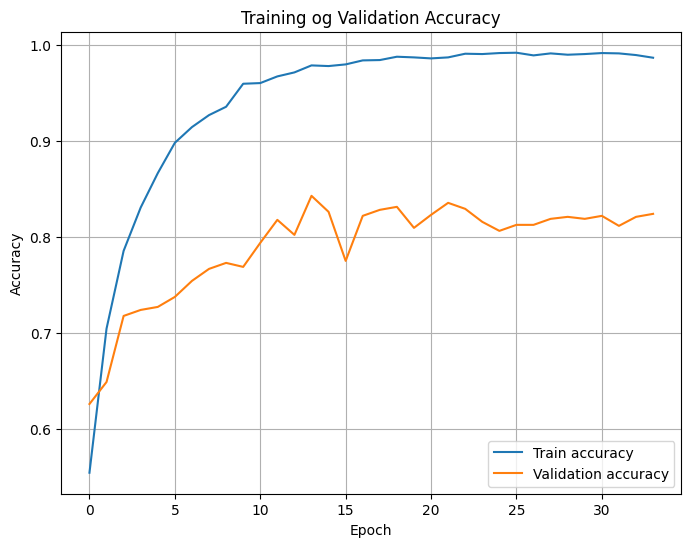

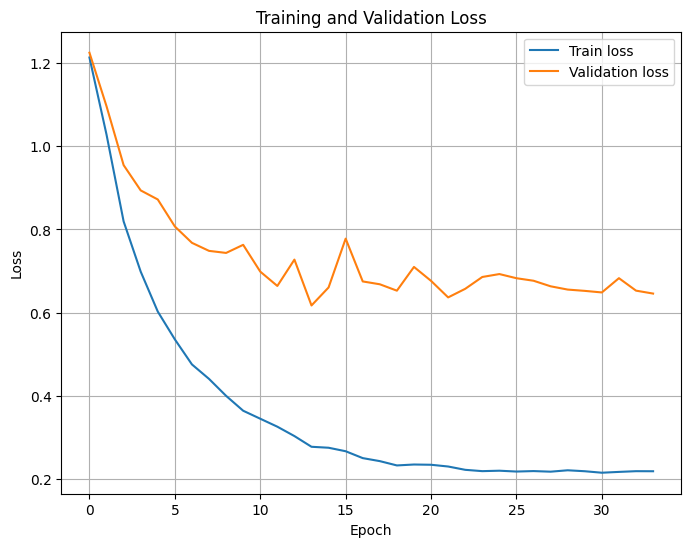

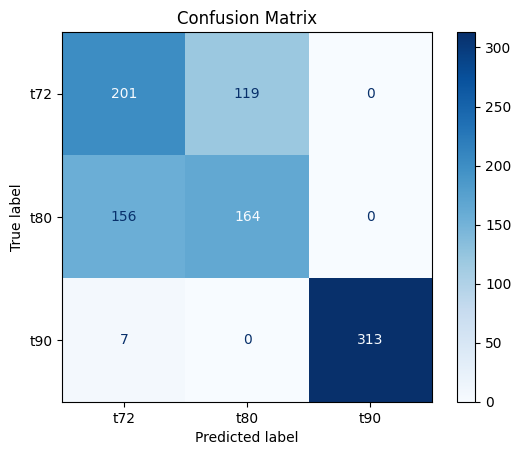


Classification Report:
              precision    recall  f1-score   support

         t72       0.55      0.63      0.59       320
         t80       0.58      0.51      0.54       320
         t90       1.00      0.98      0.99       320

    accuracy                           0.71       960
   macro avg       0.71      0.71      0.71       960
weighted avg       0.71      0.71      0.71       960

Sequence-level accuracy (majority vote): 0.7083


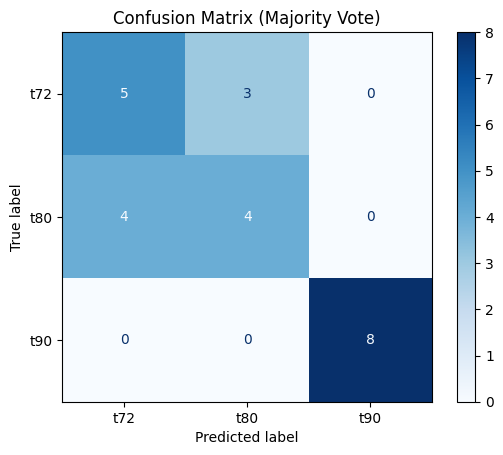


Classification Report (Majority Vote):
              precision    recall  f1-score   support

         t72       0.56      0.62      0.59         8
         t80       0.57      0.50      0.53         8
         t90       1.00      1.00      1.00         8

    accuracy                           0.71        24
   macro avg       0.71      0.71      0.71        24
weighted avg       0.71      0.71      0.71        24

Misclassified images: 282
Fil: F:\Users\Nikol\Desktop\Data\Splits1\test\t72\t72_A3s_A3_D1_L2_B1_C1_P1_V1.JPG
  True: t72
  Pred: t80
  Confidence: 0.990

Fil: F:\Users\Nikol\Desktop\Data\Splits1\test\t72\t72_A3s_A3_D1_L2_B1_C1_P1_V10.JPG
  True: t72
  Pred: t80
  Confidence: 0.971

Fil: F:\Users\Nikol\Desktop\Data\Splits1\test\t72\t72_A3s_A3_D1_L2_B1_C1_P1_V2.JPG
  True: t72
  Pred: t80
  Confidence: 0.959

Fil: F:\Users\Nikol\Desktop\Data\Splits1\test\t72\t72_A3s_A3_D1_L2_B1_C1_P1_V3.JPG
  True: t72
  Pred: t80
  Confidence: 0.991

Fil: F:\Users\Nikol\Desktop\Data\Splits1

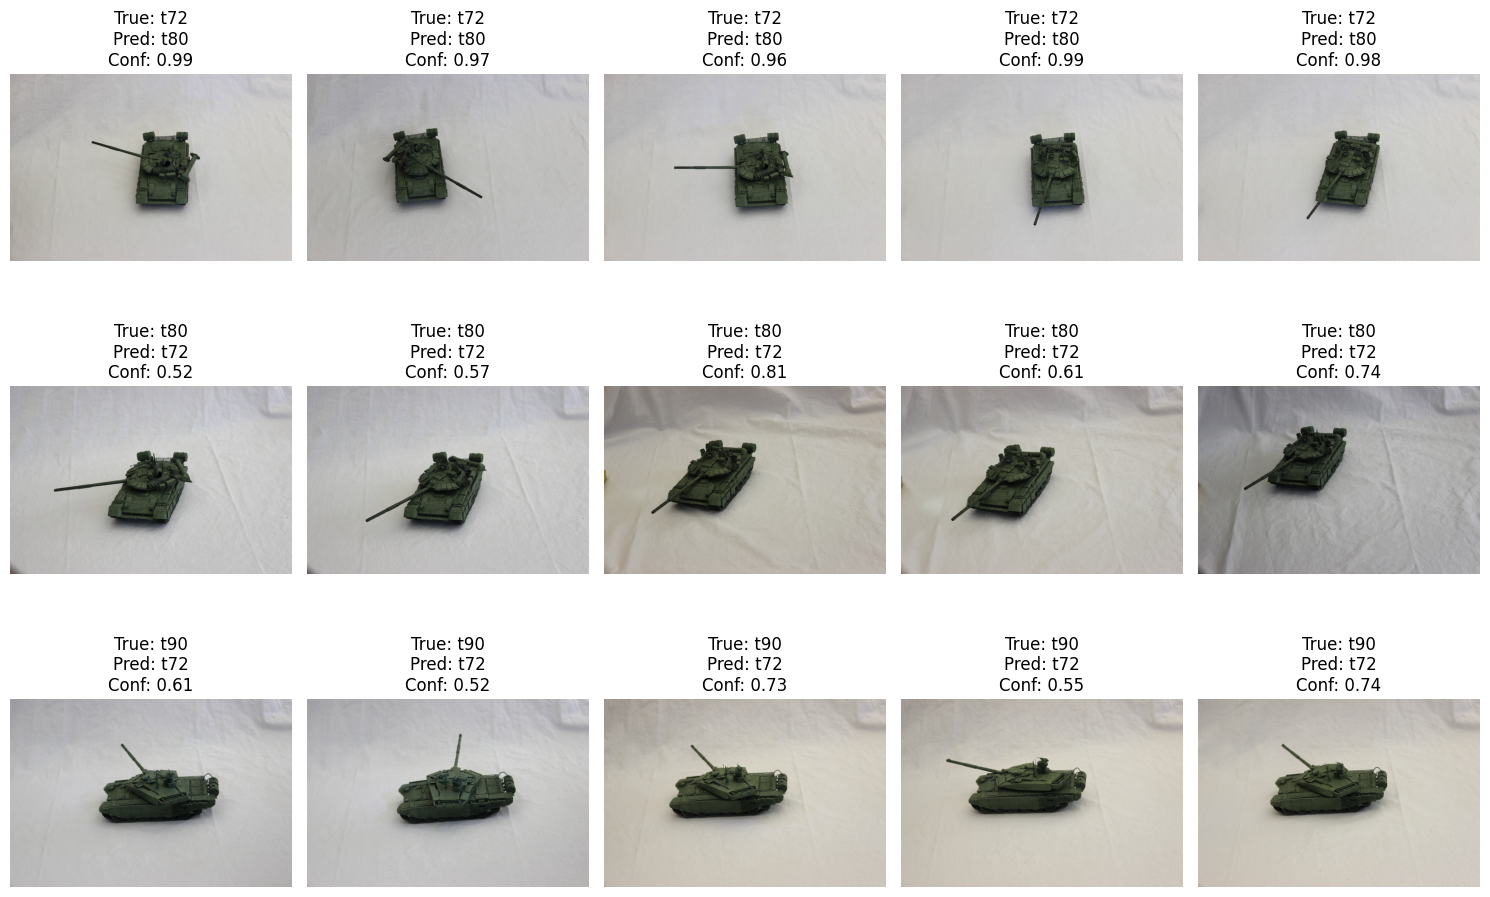

Last conv layer: top_conv


C:\Users\Nikolaj\AppData\Local\Temp\ipykernel_15044\3823419922.py:228: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = mpl_cm.get_cmap("jet")


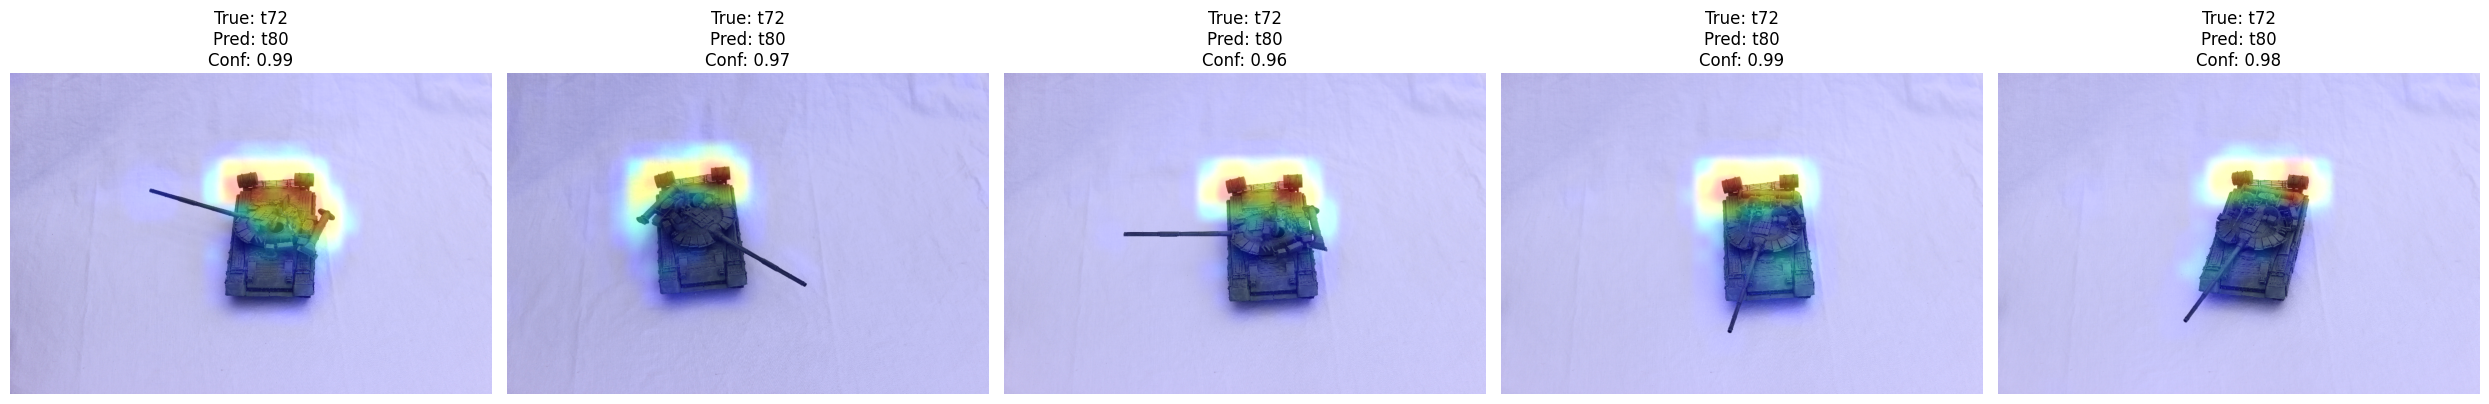

In [ ]:
# Plot training and validation curves.
plt.figure(figsize=(8, 6))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Evaluate the model on the held-out test set.
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Sequence-level evaluation using majority vote over windows of frames.
SEQUENCE_SIZE = 40

def evaluate_with_majority_vote(model, test_dir, class_names, img_size):
    """Compute sequence predictions by taking the majority vote per frame group."""
    y_true_seq = []
    y_pred_seq = []

    for class_idx, class_name in enumerate(class_names):
        class_dir = Path(test_dir) / class_name
        files = sorted([
            f for f in class_dir.iterdir()
            if f.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp")
        ])

        sequences = [files[i:i+SEQUENCE_SIZE] for i in range(0, len(files), SEQUENCE_SIZE)]
        for seq in sequences:
            frame_preds = []
            for img_path in seq:
                img = keras.utils.load_img(img_path, target_size=img_size)
                img_array = keras.utils.img_to_array(img)
                img_array = keras.applications.efficientnet.preprocess_input(img_array)
                img_array = np.expand_dims(img_array, axis=0)
                pred = np.argmax(model.predict(img_array, verbose=0))
                frame_preds.append(pred)

            majority = Counter(frame_preds).most_common(1)[0][0]
            y_true_seq.append(class_idx)
            y_pred_seq.append(majority)

    return y_true_seq, y_pred_seq


y_true_seq, y_pred_seq = evaluate_with_majority_vote(model, test_dir, class_names, img_size)

seq_acc = np.mean(np.array(y_true_seq) == np.array(y_pred_seq))
print(f"Sequence-level accuracy (majority vote): {seq_acc:.4f}")

cm_seq = confusion_matrix(y_true_seq, y_pred_seq)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_seq, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Majority Vote)")
plt.show()

print("\nClassification Report (Majority Vote):")
print(classification_report(y_true_seq, y_pred_seq, target_names=class_names))

# Collect file paths for all test images so misclassified examples can be mapped to filenames.
test_file_paths = []
for class_name in sorted(class_names):  
    class_dir = Path(test_dir) / class_name
    files = sorted([
        f for f in class_dir.iterdir()
        if f.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp")
    ])
    test_file_paths.extend([str(f) for f in files])

# Find and list misclassified test images.
misclassified = []
file_index = 0

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    confidences = np.max(predictions, axis=1)
    batch_size_actual = images.shape[0]

    for i in range(batch_size_actual):
        true_label = int(labels[i].numpy())
        pred_label = int(predicted_labels[i])

        if true_label != pred_label:
            misclassified.append({
                "file_path": test_file_paths[file_index],
                "true_label": class_names[true_label],
                "pred_label": class_names[pred_label],
                "confidence": float(confidences[i]),
            })
        file_index += 1

print(f"Misclassified images: {len(misclassified)}")

for item in misclassified[:20]:
    print(
        f"File: {item['file_path']}\n"
        f"  True: {item['true_label']}\n"
        f"  Pred: {item['pred_label']}\n"
        f"  Confidence: {item['confidence']:.3f}\n"
    )

# Show a sample of misclassified images with labels and confidence.
def show_misclassified_images(misclassified, num_images=15):
    by_class = defaultdict(list)
    for item in misclassified:
        by_class[item["true_label"]].append(item)

    sampled = []
    per_class = max(1, num_images // len(by_class))
    for items in by_class.values():
        sampled.extend(items[:per_class])
    sampled = sampled[:num_images]

    plt.figure(figsize=(15, 10))
    for i, item in enumerate(sampled):
        img = keras.utils.load_img(item["file_path"], target_size=img_size)
        img_array = keras.utils.img_to_array(img).astype("uint8")

        plt.subplot(3, 5, i + 1)
        plt.imshow(img_array)
        plt.title(
            f"True: {item['true_label']}\nPred: {item['pred_label']}\nConf: {item['confidence']:.2f}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_misclassified_images(misclassified, num_images=15)

# Grad-CAM visualization to inspect where the model looks in misclassified images.
last_conv_layer_name = None
for layer in reversed(base_model.layers):
    if isinstance(layer, layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last conv layer:", last_conv_layer_name)
last_conv_layer = base_model.get_layer(last_conv_layer_name)

feature_extractor = keras.Model(
    inputs=base_model.input,
    outputs=[last_conv_layer.output, base_model.output],
)

classifier_input = keras.Input(shape=base_model.output.shape[1:])
x = classifier_input
passed_base = False
for layer in model.layers:
    if passed_base:
        x = layer(x)
    if layer == base_model:
        passed_base = True

classifier_model = keras.Model(classifier_input, x)

def make_gradcam_heatmap(img_array_preprocessed, pred_index=None):
    with tf.GradientTape() as tape:
        last_conv_output, base_output = feature_extractor(img_array_preprocessed, training=False)
        tape.watch(last_conv_output)
        preds = classifier_model(base_output, training=False)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val

    return heatmap.numpy()


def get_gradcam_overlay(img_path, alpha=0.4):
    img = keras.utils.load_img(img_path, target_size=img_size)
    img_array = keras.utils.img_to_array(img).astype("float32")
    original_img = img_array.astype("uint8")

    input_array = np.expand_dims(img_array.copy(), axis=0)
    input_array = keras.applications.efficientnet.preprocess_input(input_array)

    preds = model.predict(input_array, verbose=0)
    pred_index = int(np.argmax(preds[0]))

    heatmap = make_gradcam_heatmap(input_array, pred_index=pred_index)

    heatmap = np.uint8(255 * heatmap)
    jet = mpl_cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((original_img.shape[1], original_img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + original_img
    superimposed_img = np.clip(superimposed_img / 255.0, 0, 1)

    return superimposed_img


def show_gradcam_images(misclassified, num_images=5):
    num_images = min(num_images, len(misclassified))
    cols = 5
    rows = int(np.ceil(num_images / cols))

    plt.figure(figsize=(5 * cols, 4 * rows))

    for i, item in enumerate(misclassified[:num_images]):
        gradcam_img = get_gradcam_overlay(item["file_path"], alpha=0.4)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(gradcam_img)
        plt.title(
            f"True: {item['true_label']}\nPred: {item['pred_label']}\nConf: {item['confidence']:.2f}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_gradcam_images(misclassified, num_images=5)